# Section 1: Imports and Feature Definitions

In this section, we import the necessary scientific computing, deep learning, and visualization libraries. We also define the feature columns and target variable for the LSTM model.

In [32]:
from __future__ import annotations

import os
from typing import Dict, Any

import joblib
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Features and target variable
FEATURES = ["movement_id", "scats_number", "dayofweek", "isweekend", "hour"]
TARGET = "hourly_traffic_volume"

# Section 2: Helper & Validation Functions

Here, we define standard helper functions to parse departure time formats and validate user inputs.

In [33]:
def hhmm_to_hour(time_hhmm: str | int) -> int:
    """
    Convert HHMM input into hour.
    Example:
        1100 -> 11
        0830 -> 8
    """
    time_text = str(time_hhmm).strip().zfill(4)

    if len(time_text) != 4 or not time_text.isdigit():
        raise ValueError("Time must be in HHMM format, for example 1100 or 0830.")

    hour = int(time_text[:2])
    minute = int(time_text[2:])

    if hour < 0 or hour > 23:
        raise ValueError("Hour must be between 00 and 23.")

    if minute < 0 or minute > 59:
        raise ValueError("Minute must be between 00 and 59.")

    return hour


def validate_dayofweek(dayofweek: int) -> int:
    """Validate dayofweek where Monday=0 and Sunday=6."""
    dayofweek = int(dayofweek)

    if dayofweek < 0 or dayofweek > 6:
        raise ValueError("dayofweek must be 0 to 6. Monday=0, Sunday=6.")

    return dayofweek

# Section 3: Data Loading and Cleaning

This section implements the data loader. It cleans datatypes, parses datetime strings, and chronologically sorts records.

In [34]:
def load_traffic_data(csv_path: str) -> pd.DataFrame:
    """
    Load and clean processed traffic_data.csv.
    """
    df = pd.read_csv(csv_path)

    required_columns = [
        "movement_id",
        "scats_number",
        "DateTime",
        "dayofweek",
        "isweekend",
        "hourly_traffic_volume",
    ]

    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in traffic data: {missing}")

    df["DateTime"] = pd.to_datetime(df["DateTime"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["DateTime"])

    df["movement_id"] = df["movement_id"].astype(str)
    df["scats_number"] = df["scats_number"].astype(int)
    df["dayofweek"] = df["dayofweek"].astype(int)
    df["isweekend"] = df["isweekend"].astype(int)
    df[TARGET] = df[TARGET].astype(float)

    # Extract hour from DateTime.
    df["hour"] = df["DateTime"].dt.hour.astype(int)

    # Keep records in time order to avoid data leakage during train/test split.
    df = df.sort_values(["DateTime", "movement_id"]).reset_index(drop=True)

    return df

# Section 4: Split Train/Test Set

In this section, we split the data chronologically (80% train, 20% test) to prevent time-series data leakage.

In [35]:
def time_based_train_test_split(df: pd.DataFrame, train_ratio: float = 0.8):
    """
    Split data by DateTime chronologically.
    """
    if not 0 < train_ratio < 1:
        raise ValueError("train_ratio must be between 0 and 1.")

    unique_times = np.sort(df["DateTime"].unique())

    if len(unique_times) < 2:
        raise ValueError("Not enough unique DateTime values for train/test split.")

    cutoff = unique_times[int(len(unique_times) * train_ratio)]

    train_df = df[df["DateTime"] < cutoff].copy()
    test_df = df[df["DateTime"] >= cutoff].copy()

    return train_df, test_df, cutoff

# Section 5: Feature Engineering / Pipeline Setup

For sequence models, we scale feature columns using `MinMaxScaler` and normalized division, then slice the dataset into standard rolling sequence inputs.

In [36]:
def prepare_sequences(df: pd.DataFrame, window_size: int = 12, train_ratio: float = 0.8):
    # Chronological cutoff
    unique_times = np.sort(df["DateTime"].unique())
    cutoff = unique_times[int(len(unique_times) * train_ratio)]
    
    train_df = df[df["DateTime"] < cutoff].copy()
    test_df = df[df["DateTime"] >= cutoff].copy()
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_df["scaled_volume"] = scaler.fit_transform(train_df[[TARGET]])
    test_df["scaled_volume"] = scaler.transform(test_df[[TARGET]])
    
    # Scale hours (0-23) and day of week (0-6)
    train_df["scaled_hour"] = train_df["hour"] / 23.0
    test_df["scaled_hour"] = test_df["hour"] / 23.0
    train_df["scaled_dayofweek"] = train_df["dayofweek"] / 6.0
    test_df["scaled_dayofweek"] = test_df["dayofweek"] / 6.0
    
    feature_cols = ["scaled_volume", "scaled_hour", "scaled_dayofweek"]
    
    X_train, y_train = [], []
    X_test, y_test = [], []
    test_dates = []
    test_movements = []
    
    # Group by movement ID to prevent cross-movement sequence blending
    for movement_id, group in df.groupby("movement_id"):
        group_train = train_df[train_df["movement_id"] == movement_id].sort_values("DateTime").reset_index(drop=True)
        group_test = test_df[test_df["movement_id"] == movement_id].sort_values("DateTime").reset_index(drop=True)
        
        combined_group = pd.concat([group_train, group_test], axis=0).reset_index(drop=True)
        feature_vals = combined_group[feature_cols].values
        target_vals = combined_group["scaled_volume"].values
        dates_vals = combined_group["DateTime"].values
        
        for i in range(window_size, len(combined_group)):
            seq_x = feature_vals[i - window_size : i]
            seq_y = target_vals[i]
            date_curr = dates_vals[i]
            
            if date_curr < cutoff:
                X_train.append(seq_x)
                y_train.append(seq_y)
            else:
                X_test.append(seq_x)
                y_test.append(seq_y)
                test_dates.append(date_curr)
                test_movements.append(movement_id)
                
    return (
        np.array(X_train), np.array(y_train),
        np.array(X_test), np.array(y_test),
        scaler, cutoff, test_dates, test_movements
    )

# Section 6: Model Architecture & Compilation

Here, we compile a deep LSTM network using TensorFlow Keras. The model uses 2 LSTM layers, dropout layers for regularization, and is trained with Adam optimizer.

In [37]:
def build_lstm_model(input_shape) -> Sequential:
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# Section 7: Model Training & Serialization

In this section, we execute model training. The resulting Keras model is saved to `.keras`, the scaler/metadata bundle to `.joblib`, and training evaluation metrics are written to a CSV report.

In [38]:
def evaluate_model(y_true, y_pred) -> Dict[str, float]:
    """Return regression evaluation metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
    }

def train_lstm(
    data_path: str,
    output_path: str,
    metadata_output_path: str,
    metrics_output_path: str,
    window_size: int = 12,
    train_ratio: float = 0.8,
) -> Dict[str, Any]:
    df = load_traffic_data(data_path)
    X_train, y_train, X_test, y_test, scaler, cutoff, _, _ = prepare_sequences(
        df, window_size=window_size, train_ratio=train_ratio
    )
    
    model = build_lstm_model((X_train.shape[1], X_train.shape[2]))

    print("Training LSTM model...")
    print(f"Training sequences: {len(X_train)}")
    print(f"Testing sequences : {len(X_test)}")
    print(f"Cutoff time        : {pd.to_datetime(cutoff)}")
    
    model.fit(X_train, y_train, epochs=25, batch_size=64, validation_split=0.1, shuffle=False)
    
    # Make predictions and inverse scale them
    predictions_scaled = model.predict(X_test)
    predictions = scaler.inverse_transform(predictions_scaled).flatten()
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    metrics = evaluate_model(y_test_original, predictions)

    # Save keras model
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    model.save(output_path)
    
    # Save metadata
    movement_to_scats = (
        df[["movement_id", "scats_number"]]
        .drop_duplicates()
        .set_index("movement_id")["scats_number"]
        .to_dict()
    )
    metadata = {
        "scaler": scaler,
        "features": FEATURES,
        "target": TARGET,
        "movement_to_scats": movement_to_scats,
        "metrics": metrics,
        "window_size": window_size,
    }
    joblib.dump(metadata, metadata_output_path)

    # Save metrics in simple key-value report format.
    metrics_text = (
        f"Model : LSTMRegressor\n"
        f"Target: {TARGET}\n"
        f"Features: {', '.join(FEATURES)}\n"
        f"Training Sequences: {len(X_train)}\n"
        f"Testing Sequences : {len(X_test)}\n"
        f"Cutoff Datetime: {pd.to_datetime(cutoff)}\n"
        f"MAE : {metrics['MAE']:.2f}\n"
        f"RMSE: {metrics['RMSE']:.2f}\n"
        f"R2  : {metrics['R2']:.4f}\n"
    )

    os.makedirs(os.path.dirname(metrics_output_path), exist_ok=True)
    with open(metrics_output_path, "w", encoding="utf-8") as file:
        file.write(metrics_text)

    print("\nLSTM Evaluation")
    print(f"MAE : {metrics['MAE']:.2f}")
    print(f"RMSE: {metrics['RMSE']:.2f}")
    print(f"R2  : {metrics['R2']:.4f}")
    print(f"\nSaved model     : {output_path}")
    print(f"Saved metadata  : {metadata_output_path}")
    print(f"Saved metrics   : {metrics_output_path}")

    return metadata

# Section 8: Model Evaluation Visualization

Here, we visualize the model predictions against the actual test set target values using a scatter plot and sequential timeline comparison.

Training LSTM model...
Training sequences: 37264
Testing sequences : 9512
Cutoff time        : 2006-10-25 19:00:00
Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


525/525 ━━━━━━━━━━━━━━━━━━━━ 31s 48ms/step - loss: 0.0154 - val_loss: 0.0045
Epoch 2/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - loss: 0.0081 - val_loss: 0.0032
Epoch 3/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - loss: 0.0049 - val_loss: 0.0020
Epoch 4/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 5/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - loss: 0.0026 - val_loss: 0.0015
Epoch 11/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - loss: 0.0025 - val_loss: 0.0015
Epoch 12/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - loss: 0.0024 - val_loss: 0.0014
Epoch 13/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 14/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - loss: 0.0023 - val_loss: 0.0013
Epoch 15/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - loss: 0.0023 - val_loss: 0.0013
Epoch 16/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 26s 49ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 17/25
525/525 ━━━━━━━━━━━━━━━━━

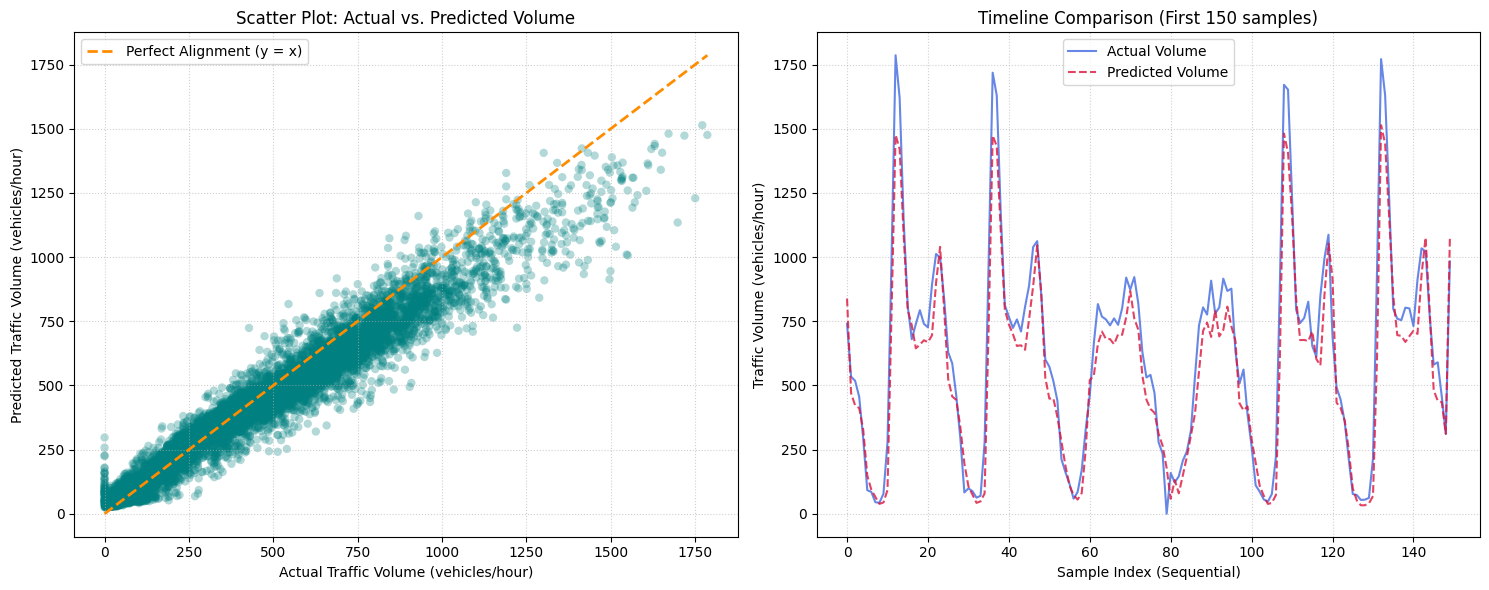

In [40]:
DATA_PATH = "../data/processed/traffic_data.csv"
MODEL_OUT_PATH = "../models_saved/lstm_model.keras"
METADATA_OUT_PATH = "../models_saved/lstm_metadata.joblib"
METRICS_OUT_PATH = "../models_saved/lstm_metrics.csv"

metadata = train_lstm(
    data_path=DATA_PATH,
    output_path=MODEL_OUT_PATH,
    metadata_output_path=METADATA_OUT_PATH,
    metrics_output_path=METRICS_OUT_PATH
)

import matplotlib.pyplot as plt

# Load test data for visualization
df = load_traffic_data(DATA_PATH)
_, _, X_test, y_test, scaler, _, _, _ = prepare_sequences(
    df, window_size=metadata["window_size"], train_ratio=0.8
)

model = tf.keras.models.load_model(MODEL_OUT_PATH)
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

plt.figure(figsize=(15, 6))

# Plot 1: Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_actual, y_pred, alpha=0.3, color="teal", edgecolors="none")
max_val = max(y_actual.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], color="darkorange", linestyle="--", lw=2, label="Perfect Alignment (y = x)")
plt.xlabel("Actual Traffic Volume (vehicles/hour)")
plt.ylabel("Predicted Traffic Volume (vehicles/hour)")
plt.title("Scatter Plot: Actual vs. Predicted Volume")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

# Plot 2: Timeline comparison
plt.subplot(1, 2, 2)
subset_size = min(150, len(y_actual))
plt.plot(np.arange(subset_size), y_actual[:subset_size], label="Actual Volume", color="royalblue", alpha=0.8, lw=1.5)
plt.plot(np.arange(subset_size), y_pred[:subset_size], label="Predicted Volume", color="crimson", alpha=0.8, linestyle="--", lw=1.5)
plt.xlabel("Sample Index (Sequential)")
plt.ylabel("Traffic Volume (vehicles/hour)")
plt.title(f"Timeline Comparison (First {subset_size} samples)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

# Section 9: Edge Predictions Batch Run

Finally, we load the road network topology, reconstruct the historical sequence context from our database, and generate batch predictions for all network edges at a specific time and day (e.g. 11:00 AM on Monday).

In [41]:
def predict_for_edges(
    model_path: str,
    metadata_path: str,
    data_path: str,
    edges_path: str,
    time_hhmm: str | int,
    dayofweek: int = 0,
    output_csv_path: str | None = None,
) -> pd.DataFrame:
    meta = joblib.load(metadata_path)
    scaler = meta["scaler"]
    window_size = meta["window_size"]
    movement_to_scats = meta.get("movement_to_scats", {})

    model = tf.keras.models.load_model(model_path)
    edges_df = pd.read_csv(edges_path)
    traffic_df = load_traffic_data(data_path)
    
    # Standardize scaling
    traffic_df["scaled_volume"] = scaler.transform(traffic_df[[TARGET]])
    traffic_df["scaled_hour"] = traffic_df["hour"] / 23.0
    traffic_df["scaled_dayofweek"] = traffic_df["dayofweek"] / 6.0
    
    feature_cols = ["scaled_volume", "scaled_hour", "scaled_dayofweek"]
    hour = hhmm_to_hour(time_hhmm)
    dayofweek = validate_dayofweek(dayofweek)
    isweekend = 1 if dayofweek in [5, 6] else 0

    prediction_rows = []
    X_pred_list = []
    valid_edges = []

    for idx, edge in edges_df.iterrows():
        movement_id = str(edge["movement_id"])
        scats_number = movement_to_scats.get(movement_id, edge["from_site"])
        
        # Retrieve historical sequence context for this movement ID
        hist_group = traffic_df[traffic_df["movement_id"] == movement_id].sort_values("DateTime").reset_index(drop=True)
        
        if len(hist_group) < window_size:
            # Fallback if history is insufficient
            dummy_feature = np.zeros((window_size, len(feature_cols)))
            X_pred_list.append(dummy_feature)
        else:
            # Extract the latest sequence context window
            seq_features = hist_group[feature_cols].values[-window_size:]
            X_pred_list.append(seq_features)
            
        valid_edges.append(edge)

    X_pred = np.array(X_pred_list)
    predicted_scaled = model.predict(X_pred)
    predicted_flow = scaler.inverse_transform(predicted_scaled).flatten()
    predicted_flow = np.maximum(0, predicted_flow)

    result = pd.DataFrame(valid_edges)
    result["prediction_time_hhmm"] = str(time_hhmm).zfill(4)
    result["dayofweek"] = dayofweek
    result["predicted_hourly_traffic_volume"] = predicted_flow.round(2)

    if output_csv_path:
        os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)
        result.to_csv(output_csv_path, index=False)
        print(f"Saved edge predictions: {output_csv_path}")

    return result

EDGES_PATH = "../data/processed/edges.csv"
PRED_OUT_PATH = "../data/processed/lstm_edge_predictions.csv"

predictions_df = predict_for_edges(
    model_path=MODEL_OUT_PATH,
    metadata_path=METADATA_OUT_PATH,
    data_path=DATA_PATH,
    edges_path=EDGES_PATH,
    time_hhmm="1100",
    dayofweek=0,
    output_csv_path=PRED_OUT_PATH
)

predictions_df.head()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
Saved edge predictions: ../data/processed/lstm_edge_predictions.csv


,from_site,to_site,straight_distance_km,travel_distance_km,base_time_min,movement_id,prediction_time_hhmm,dayofweek,predicted_hourly_traffic_volume
0,2820,4321,1.77,3.70,4,2820_2,1100,0,128.220001
1,2820,3662,1.59,1.87,2,2820_1,1100,0,59.290001
2,3662,3002,0.60,1.03,1,3662_3,1100,0,159.970001
3,3002,4263,0.85,1.17,1,3002_3,1100,0,102.680000
4,3002,4266,1.85,2.68,3,3002_2,1100,0,119.730003
